In [66]:
import numpy as np
import torch
import torch.nn as nn
import openml
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [57]:
dataset = openml.datasets.get_dataset("liver-disorders").get_data()[0]
TARGET_COL = "drinks"
X = torch.tensor(dataset[dataset.columns.drop(TARGET_COL)].to_numpy(), dtype=torch.float)
y = torch.tensor(dataset[TARGET_COL].to_numpy(), dtype=torch.float).reshape(-1, 1)

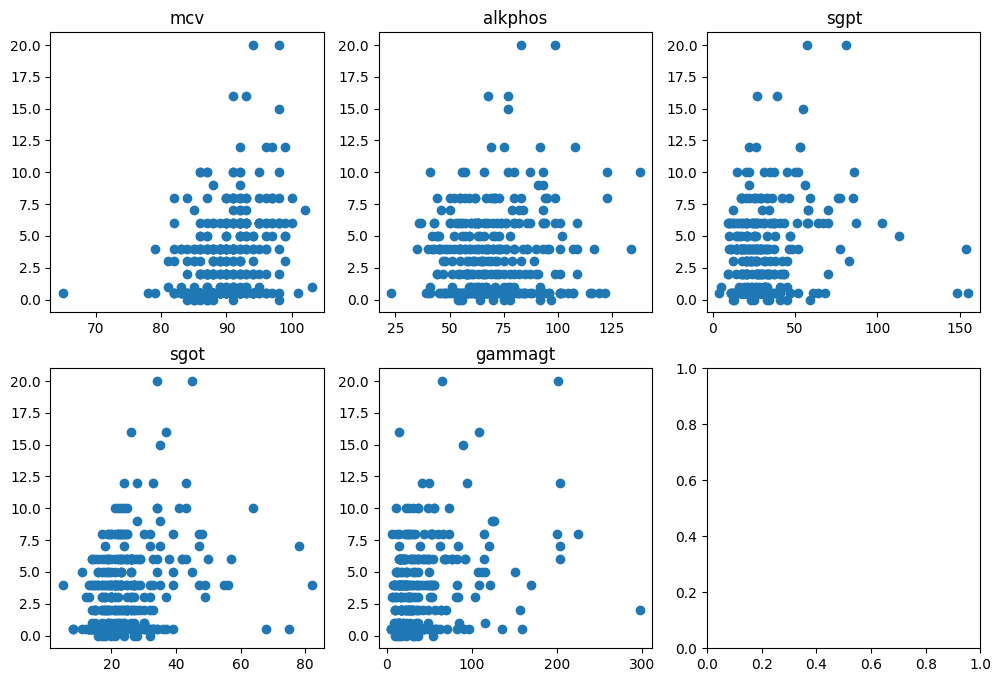

In [54]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs = axs.flatten()

for i in range(X.shape[1]):
    ax = axs[i]
    ax.scatter(X[:, i], y)
    ax.set_title(dataset.columns.drop(TARGET_COL)[i])

In [55]:
class MLP(nn.Module):
    def __init__(self, n_hidden: int, n_width: int):
        super().__init__()

        self.input_layer = nn.Linear(X.shape[1], n_width)
        self.hidden_layers = nn.ModuleList([nn.Linear(n_width, n_width) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(n_width, 1)
        self.relu = nn.ReLU()

        self.train_losses = []
        self.test_losses = []
        self.train_rsq = []
        self.test_rsq = []

    def forward(self, x):
        x = self.relu(self.input_layer(x))

        for layer in self.hidden_layers:
            x = self.relu(layer(x))

        x = self.output_layer(x)
        return x

In [91]:
def train_new_model(n_hidden: int, n_width: int, n_epochs: int, X_train, y_train, X_test, y_test):
    model = MLP(n_hidden, n_width)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # SStot_train = np.sum(np.power(y_train - np.mean(y_train), 2))
    # SStot_test = np.sum(np.power(y_test - np.mean(y_test), 2))

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        model.train()

        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)

        loss.backward()
        optimizer.step()

        model.train_losses.append(loss.item())

        # SSres = np.sum(np.power(y_train - y_pred, 2))
        # model.train_rsq.append(1 - SSres/SStot_train)

        model.eval()
        with torch.no_grad():
            y_pred = model(X_test)
            loss = loss_fn(y_pred, y_test)
            model.test_losses.append(loss.item())

            # SSres = np.sum(np.power(y_train - y_pred, 2))
            # model.train_rsq.append(1 - SSres/SStot_test)

    return model


In [80]:
def train_k_fold_models(n_hidden: int, n_width: int, n_epochs: int) -> list[MLP]:
    skf = KFold(n_splits=5, shuffle=True, random_state=42)

    k_models = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = train_new_model(n_hidden, n_width, n_epochs, X_train, y_train, X_test, y_test)
        k_models.append(model)

    return k_models

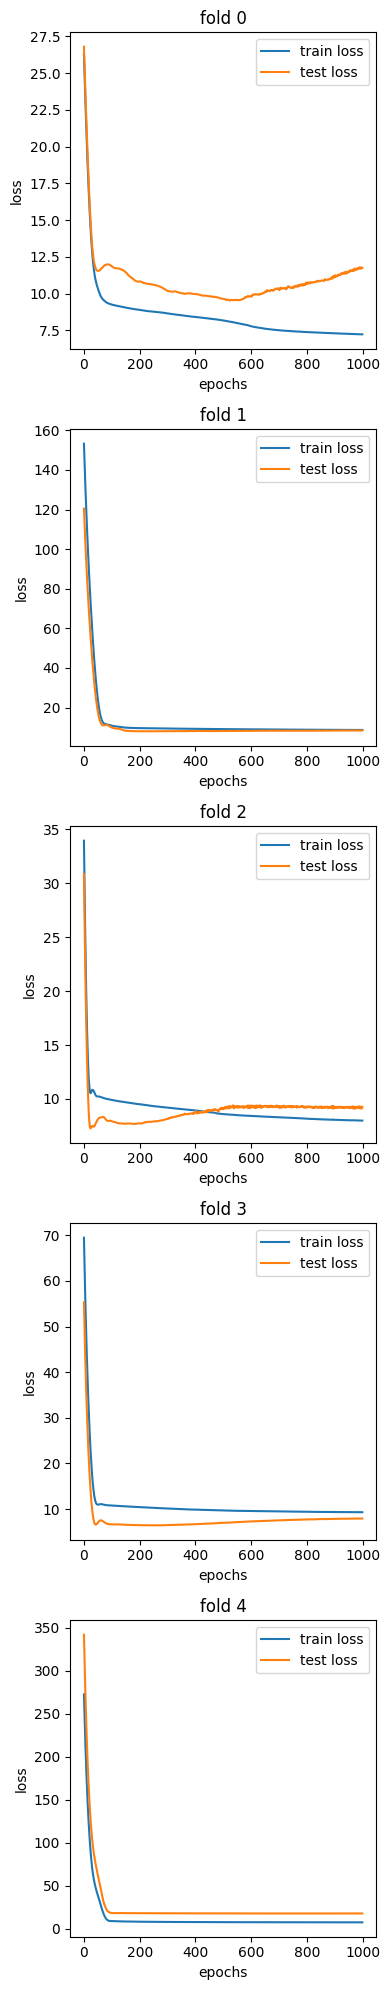

In [92]:
k_models = train_k_fold_models(1, 10, 1000)

fig, axs = plt.subplots(len(k_models), 1, figsize=(4, 4*len(k_models)))
axs = axs.reshape(len(k_models), -1)

for idx, model in enumerate(k_models):
    ax = axs[idx, 0]

    epochs_axis = np.arange(len(model.train_losses))
    ax.plot(epochs_axis, model.train_losses, label="train loss")
    ax.plot(epochs_axis, model.test_losses, c="tab:orange", label="test loss")
    ax.set_xlabel("epochs")
    ax.set_ylabel("loss")
    ax.legend()

    ax.set_title(f"fold {idx}")

plt.tight_layout()
plt.show()